In [1]:
import os
os.chdir('..')

In [2]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [3]:
import datetime
import numpy as np
import pandas as pd
from scipy.io import loadmat
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn import metrics
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import random as rnd

# Data Preprocessing


Data preprocessing to divide the data into sequences of 10 observations in each cycle, the sequence have overlap with eachother.

In [4]:
def generate_sequences(data, window_size):
    X, y_capacity, y_RUL, y_SOH = [], [], [], []
    cyclic_RUL_x, cyclic_RUL_y = [], []

    cycles = data['cycle'].unique()
    initial_capacity = data.iloc[0]['capacity']

    # Normalize all 'capacity' values by the first row's 'capacity' value
    data['SOH'] = data['capacity'] / initial_capacity

    # dividing the data of each cycle into sequences
    for cycle in cycles:
        cycle_data = data[data['cycle'] == cycle]
        cycle_observations = []
        num_rows = len(cycle_data)

        if num_rows >= window_size:
            for start in range(num_rows - window_size + 1):
                end = start + window_size

                features = cycle_data.iloc[start:end].drop(['cycle', 'capacity', 'RUL', 'SOH'], axis=1).values # Exclude 'cycle', 'capacity', 'RUL', 'SOH'
                target_capacity = cycle_data.iloc[end-1, cycle_data.columns.get_loc('capacity')] # Capacity target
                target_SOH = cycle_data.iloc[end-1, cycle_data.columns.get_loc('SOH')] # SOH target
                target_RUL = cycle_data.iloc[end-1, cycle_data.columns.get_loc('RUL')] # RUL target
                cycle_observations.append(features)
                X.append(features)
                y_capacity.append(target_capacity)
                y_SOH.append(target_SOH)
                y_RUL.append(target_RUL)

            cyclic_RUL_x.append(y_capacity[-1])
            cyclic_RUL_y.append(y_RUL[-1])

    return np.array(X), np.array(y_capacity), np.array(y_SOH), np.array(y_RUL), np.array(cyclic_RUL_x), np.array(cyclic_RUL_y)

In [5]:
file_path_0005 = 'dataset/csv/B0005_discharge.csv'
file_path_0006 = 'dataset/csv/B0006_discharge.csv'
file_path_0007 = 'dataset/csv/B0007_discharge.csv'
file_path_0018 = 'dataset/csv/B0018_discharge.csv'

# reading the data files
data_0005 = pd.read_csv(file_path_0005)
data_0006 = pd.read_csv(file_path_0006)
data_0007 = pd.read_csv(file_path_0007)
data_0018 = pd.read_csv(file_path_0018)

# making the sequnces for each data file
X_0005, y_capacit_0005, y_SOH_0005, y_RUL_0005, cyclic_RUL_x_0005, cyclic_RUL_y_0005 = generate_sequences(data_0005, 10)
X_0006, y_capacit_0006, y_SOH_0006,  y_RUL_0006, cyclic_RUL_x_0006, cyclic_RUL_y_0006 = generate_sequences(data_0006, 10)
X_0007, y_capacit_0007, y_SOH_0007,  y_RUL_0007, cyclic_RUL_x_0007, cyclic_RUL_y_0007 = generate_sequences(data_0007, 10)
X_0018, y_capacit_0018, y_SOH_0018,  y_RUL_0018, cyclic_RUL_x_0018, cyclic_RUL_y_0018 = generate_sequences(data_0018, 10)

In [6]:
# concatenating the data
X = np.concatenate((X_0005, X_0006, X_0007, X_0018), axis=0)
y_capacity = np.concatenate((y_capacit_0005, y_capacit_0006, y_capacit_0007, y_capacit_0018), axis=0)
y_SOH = np.concatenate((y_SOH_0005, y_SOH_0006, y_SOH_0007, y_SOH_0018), axis=0)
y_RUL = np.concatenate((y_RUL_0005, y_RUL_0006, y_RUL_0007, y_RUL_0018), axis=0)
cyclic_RUL_x = np.concatenate((cyclic_RUL_x_0005, cyclic_RUL_x_0006, cyclic_RUL_x_0007, cyclic_RUL_x_0018), axis=0)
cyclic_RUL_y = np.concatenate((cyclic_RUL_y_0005, cyclic_RUL_y_0006, cyclic_RUL_y_0007, cyclic_RUL_y_0018), axis=0)

# Predicting SOH/Capacity

## predicting raw capacity

This step is only added for the sake of comparing our method with baselines since they predict raw capacity rather than SOH, and this model is not part of our pipeline

In [7]:
# data split into train, test, validation
X_capacity_train, X_capacity_testval, y_capacity_train, y_capacity_testval = train_test_split(
    X, y_capacity, test_size=0.2, random_state=42
)

X_capacity_test, X_capacity_validation, y_capacity_test, y_capacity_validation = train_test_split(
    X_capacity_testval, y_capacity_testval, test_size=0.5, random_state=42
)

In [8]:
# architecture of model
time_steps = X_capacity_train.shape[1]
features = X_capacity_train.shape[2]

model = Sequential()

model.add(LSTM(100, return_sequences=True, input_shape=(time_steps, features)))
model.add(LSTM(100, return_sequences=True))
model.add(LSTM(100, return_sequences=False))
model.add(Dense(50, activation='relu'))
model.add(Dense(1, activation='linear'))

# model.compile(optimizer='adam', loss='mean_squared_error')
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae', 'mse']
)

D:\Deep-Learning-for-Battery-State-of-Health-SoH--main\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
# training and saving the model
history = model.fit(X_capacity_train, y_capacity_train, epochs=20, validation_data=(X_capacity_validation, y_capacity_validation), verbose=1)
model.save('Raw_Capacity_LSTM.h5')

Epoch 1/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 69s 14ms/step - loss: 0.0338 - mae: 0.1514 - mse: 0.0338 - val_loss: 0.0182 - val_mae: 0.1114 - val_mse: 0.0182
Epoch 2/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 63s 14ms/step - loss: 0.0154 - mae: 0.0973 - mse: 0.0154 - val_loss: 0.0128 - val_mae: 0.0877 - val_mse: 0.0128
Epoch 3/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 65s 14ms/step - loss: 0.0145 - mae: 0.0943 - mse: 0.0145 - val_loss: 0.0122 - val_mae: 0.0854 - val_mse: 0.0122
Epoch 4/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 66s 15ms/step - loss: 0.0141 - mae: 0.0926 - mse: 0.0141 - val_loss: 0.0148 - val_mae: 0.0941 - val_mse: 0.0148
Epoch 5/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 64s 14ms/step - loss: 0.0136 - mae: 0.0907 - mse: 0.0136 - val_loss: 0.0104 - val_mae: 0.0759 - val_mse: 0.0104
Epoch 6/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 64s 14ms/step - loss: 0.0128 - mae: 0.0873 - mse: 0.0128 - val_loss: 0.0097 - val_mae: 0.0732 - val_mse: 0.0097
Epoch 7/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 65s 15ms/step - loss: 0.0112 - mae

### testing

In [10]:
# loading the model
cap_model = load_model('Raw_Capacity_LSTM.h5')
cap_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ lstm (LSTM)                   │ (None, 10, 100)       │       43,200 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ lstm_1 (LSTM)                 │ (None, 10, 100)       │       80,400 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ lstm_2 (LSTM)                 │ (None, 100)           │       80,400 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense (Dense)                 │ (None, 50)            │        5,050 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_1 (Dense)               │ (None, 1)             │           51 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 209,103 (816.81 KB)

 Trainable params: 209,101 (816.80 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
Mean Squared Error: 0.010272968449890915
Mean Absolute Error: 0.08048420204745912
Root Mean Squared Error: 0.10135565327050541


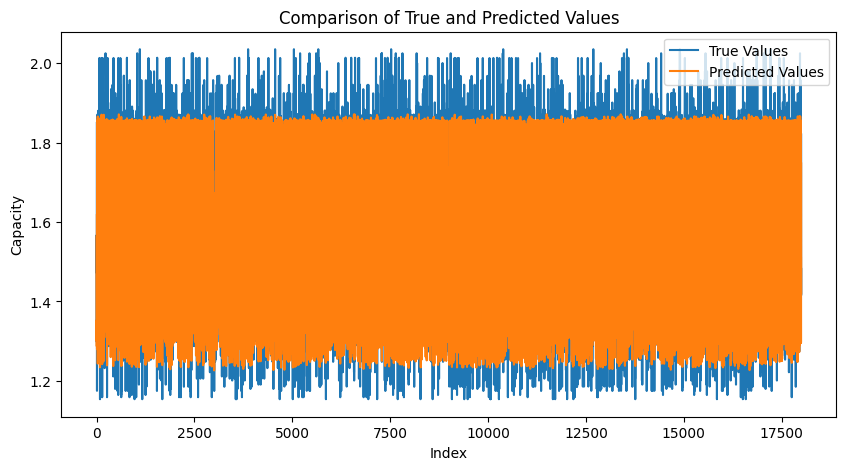

In [11]:
# testing the accuracy of model on test dataset
predicted_y = cap_model.predict(X_capacity_test)
true_y = y_capacity_test

mse = mean_squared_error(true_y, predicted_y)
mae = mean_absolute_error(true_y, predicted_y)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

plt.figure(figsize=(10, 5))

plt.plot(true_y, label='True Values')

plt.plot(predicted_y, label='Predicted Values')

plt.title('Comparison of True and Predicted Values')
plt.xlabel('Index')
plt.ylabel('Capacity')
plt.legend()
plt.show()

## predicting SOH (main method)

This is for predicting the SOH (currecnt capacity / initial capacity) which is used as input for the RUL model.

In [12]:
# spliting data into train, test, validation
X_SOH_train, X_SOH_testval, y_SOH_train, y_SOH_testval = train_test_split(
    X, y_SOH, test_size=0.2, random_state=42
)

X_SOH_test, X_SOH_validation, y_SOH_test, y_SOH_validation = train_test_split(
    X_SOH_testval, y_SOH_testval, test_size=0.5, random_state=42
)

In [13]:
# architecture of the model
time_steps = X_SOH_train.shape[1]
features = X_SOH_train.shape[2]

model = Sequential()

model.add(LSTM(100, return_sequences=True, input_shape=(time_steps, features)))
model.add(LSTM(100, return_sequences=True))
model.add(LSTM(100, return_sequences=False))
model.add(Dense(50, activation='relu'))
model.add(Dense(1, activation='linear'))

model.compile(optimizer='adam', loss='mean_squared_error')

D:\Deep-Learning-for-Battery-State-of-Health-SoH--main\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
# training the model
history = model.fit(X_SOH_train, y_SOH_train, epochs=20, validation_data=(X_SOH_validation, y_SOH_validation), verbose=1)
model.save('SOH_LSTM.h5')

Epoch 1/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 66s 14ms/step - loss: 0.0114 - val_loss: 0.0064
Epoch 2/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 61s 14ms/step - loss: 0.0053 - val_loss: 0.0048
Epoch 3/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 61s 14ms/step - loss: 0.0049 - val_loss: 0.0041
Epoch 4/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 61s 14ms/step - loss: 0.0045 - val_loss: 0.0043
Epoch 5/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 61s 14ms/step - loss: 0.0040 - val_loss: 0.0036
Epoch 6/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 61s 14ms/step - loss: 0.0036 - val_loss: 0.0031
Epoch 7/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 61s 14ms/step - loss: 0.0035 - val_loss: 0.0035
Epoch 8/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 61s 14ms/step - loss: 0.0035 - val_loss: 0.0035
Epoch 9/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 61s 14ms/step - loss: 0.0032 - val_loss: 0.0026
Epoch 10/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 61s 14ms/step - loss: 0.0031 - val_loss: 0.0044
Epoch 11/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 61s 13ms/step - loss: 0.0029 - val_loss: 0.0023
Epoch 12

### Testing

In [15]:
# loading the model
SOH_model = load_model('SOH_LSTM.h5')
SOH_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                 │ (None, 10, 100)       │       43,200 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ lstm_4 (LSTM)                 │ (None, 10, 100)       │       80,400 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ lstm_5 (LSTM)                 │ (None, 100)           │       80,400 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_2 (Dense)               │ (None, 50)            │        5,050 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_3 (Dense)               │ (None, 1)             │           51 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 209,103 (816.81 KB)

 Trainable params: 209,101 (816.80 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step
Mean Squared Error: 0.0011485759225179754
Mean Absolute Error: 0.027129274375678348
Root Mean Squared Error: 0.03389064653437546


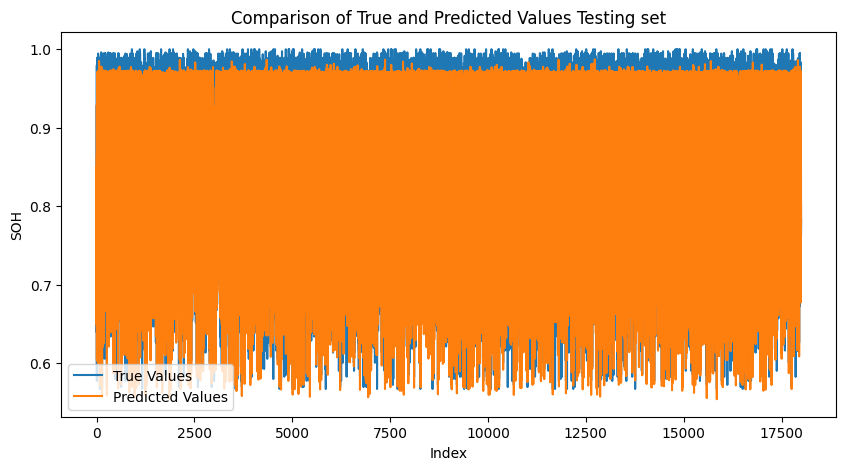

In [16]:
# testing the accuracy of model on thw test dataset
predicted_y = SOH_model.predict(X_SOH_test)
true_y = y_SOH_test

mse = mean_squared_error(true_y, predicted_y)
mae = mean_absolute_error(true_y, predicted_y)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

plt.figure(figsize=(10, 5))

plt.plot(true_y, label='True Values')

plt.plot(predicted_y, label='Predicted Values')

plt.title('Comparison of True and Predicted Values Testing set')
plt.xlabel('Index')
plt.ylabel('SOH')
plt.legend()
plt.show()

4500/4500 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step
Mean Squared Error: 0.001163652114719125
Mean Absolute Error: 0.027193113991027792
Root Mean Squared Error: 0.03411234548838771


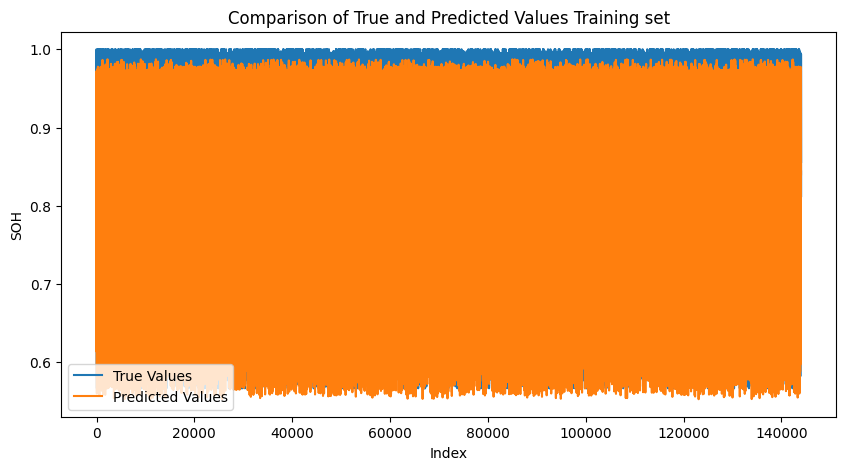

In [17]:
# testing the accuracy of model on train dataset
predicted_y = SOH_model.predict(X_SOH_train)
true_y = y_SOH_train

mse = mean_squared_error(true_y, predicted_y)
mae = mean_absolute_error(true_y, predicted_y)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

plt.figure(figsize=(10, 5))

plt.plot(true_y, label='True Values')

plt.plot(predicted_y, label='Predicted Values')

plt.title('Comparison of True and Predicted Values Training set')
plt.xlabel('Index')
plt.ylabel('SOH')
plt.legend()
plt.show()

# Predicting RUL

In [18]:
# reshaping the cyclic_RUL_x data so that each element is a numpy array
cyclic_RUL_x_reshaped = np.empty((cyclic_RUL_x.shape[0], 1))
for i in range(cyclic_RUL_x.shape[0]):
  cyclic_RUL_x_reshaped[i] = np.array([cyclic_RUL_x[i]])

In [19]:
# scaling the RUL values between 0 and 1
scaler = MinMaxScaler()
scaled_rul = scaler.fit_transform(cyclic_RUL_y.reshape(-1, 1))

In [20]:
# generating sequntial data for RUL prediction given SOH, here we use sequences of 3 cycles (not observation, note that the SOH and RUL are constant in each cycle)
def generate_sequences_RUL(capacity, RUL_GT, window_size):
  X, y_RUL = [], []
  for start in range(capacity.shape[0] - window_size + 1):
    end = start + window_size

    features = capacity[start:end]
    target_RUL = RUL_GT[end-1]
    X.append(features)
    y_RUL.append(target_RUL)

  return np.array(X), np.array(y_RUL)

In [21]:
X_for_RUL, y_RUL = generate_sequences_RUL(cyclic_RUL_x_reshaped, scaled_rul, 3)

In [22]:
# spliting the data into train, test, and validation
X_RUL_train, X_RUL_testval, y_RUL_train, y_RUL_testval = train_test_split(
    X_for_RUL, y_RUL, test_size=0.1, random_state=42
)

X_RUL_test, X_RUL_validation, y_RUL_test, y_RUL_validation = train_test_split(
    X_RUL_testval, y_RUL_testval, test_size=0.5, random_state=42
)

In [23]:
# architecture of the model
model = Sequential()
model.add(LSTM(units=200, return_sequences=True, input_shape=(X_RUL_train.shape[1],1)))
model.add(Dropout(0.3))
model.add(LSTM(units=200, return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(units=200))
model.add(Dropout(0.3))
model.add(Dense(units=50, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(units=1, activation='linear'))
model.compile(optimizer='adam',loss='mean_squared_error')

D:\Deep-Learning-for-Battery-State-of-Health-SoH--main\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [24]:
# training and saving the model
history = model.fit(X_RUL_train, y_RUL_train, epochs=200, validation_data=(X_RUL_validation, y_RUL_validation), verbose=1)
model.save('RUL_LSTM.h5')

Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 0.1341 - val_loss: 0.0861
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0739 - val_loss: 0.0577
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0674 - val_loss: 0.0534
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0585 - val_loss: 0.0423
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0463 - val_loss: 0.0253
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0338 - val_loss: 0.0160
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0278 - val_loss: 0.0080
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0241 - val_loss: 0.0365
Epoch 9/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0333 - val_loss: 0.0087
Epoch 10/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0304 - val_loss: 0.0284
Epoch 11/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0259 - val_loss: 0.0072
Epoch 12/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

### testing

In [25]:
# loading the model
RUL_model = load_model('RUL_LSTM.h5')
RUL_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                 │ (None, 3, 200)        │      161,600 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout (Dropout)             │ (None, 3, 200)        │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ lstm_7 (LSTM)                 │ (None, 3, 200)        │      320,800 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout_1 (Dropout)           │ (None, 3, 200)        │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ lstm_8 (LSTM)                 │ (None, 200)           │      320,800 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout_2 (Dropout)           │ (None, 200)           │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_4 (Dense)               │ (None, 50)            │       10,050 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout_3 (Dropout)           │ (None, 50)            │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_5 (Dense)               │ (None, 1)             │           51 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 813,303 (3.10 MB)

 Trainable params: 813,301 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 841ms/step
Mean Squared Error: 0.013068748814600593
Mean Absolute Error: 0.08654735737318499
Root Mean Squared Error: 0.11431862846710764


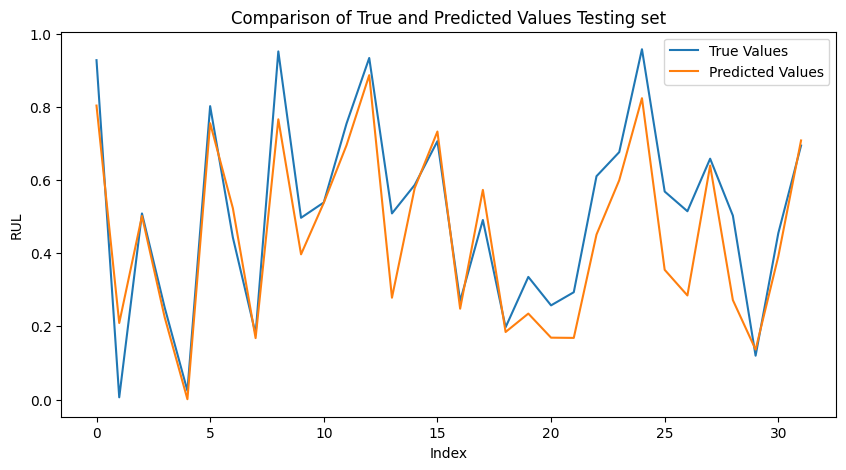

In [26]:
# testing the model on test dataset
predicted_y = RUL_model.predict(X_RUL_test)
true_y = y_RUL_test

mse = mean_squared_error(true_y, predicted_y)
mae = mean_absolute_error(true_y, predicted_y)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

plt.figure(figsize=(10, 5))

plt.plot(true_y, label='True Values')

plt.plot(predicted_y, label='Predicted Values')

plt.title('Comparison of True and Predicted Values Testing set')
plt.xlabel('Index')
plt.ylabel('RUL')
plt.legend()
plt.show()

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
Mean Squared Error: 0.008109373614170419
Mean Absolute Error: 0.07034440999638324
Root Mean Squared Error: 0.09005206057703743


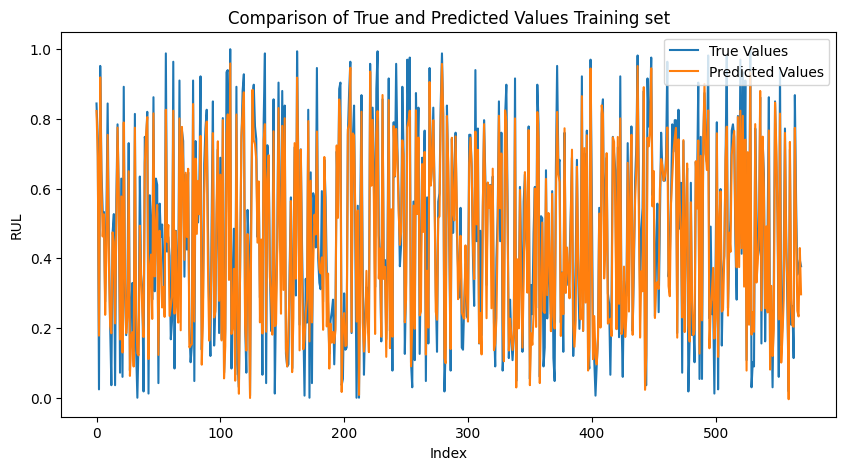

In [27]:
# testing the model on train dataset
predicted_y = RUL_model.predict(X_RUL_train)
true_y = y_RUL_train

mse = mean_squared_error(true_y, predicted_y)
mae = mean_absolute_error(true_y, predicted_y)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

plt.figure(figsize=(10, 5))

plt.plot(true_y, label='True Values')

plt.plot(predicted_y, label='Predicted Values')

plt.title('Comparison of True and Predicted Values Training set')
plt.xlabel('Index')
plt.ylabel('RUL')
plt.legend()
plt.show()